# Simulation vs. theory: 1D cross-coupling scans

For each of the three 1D scans of $J_{\mathrm{cross}}^{1\to 0}$ (at fixed $J_{\mathrm{cross}}^{0\to 1} \in \{0.020,\,0.03375,\,0.045\}$) this notebook overlays, in one figure:

- the **simulation** fixed points as **dots** (`Draw_color_graph_difference_activity.ipynb` loader), and
- the **theory** prediction as **lines** (`Draw_theory_prediction.ipynb` equations),

with distinct sim/theory colors per quantity (light dots, dark line): blue = area 0, red = area 1, purple = area difference. The black dashed line marks the theoretical stability boundary $\lambda_{\max}(W)=1$.

Helper functions are copied verbatim from the two source notebooks so this notebook is self-contained.

In [1]:
import re
import csv
import copy
import math
import json
import traceback
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
from scipy.optimize import root
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, SymLogNorm, Normalize, LinearSegmentedColormap
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Circle, Patch
from scipy.sparse import csr_matrix, diags, eye
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from dataclasses import dataclass, replace, asdict, is_dataclass
from typing import Any, Dict, Iterable, Iterator, List, Mapping, Optional, Tuple

In [2]:
# ============================================================
# Simulation-scan loader
# (verbatim from Draw_color_graph_difference_activity.ipynb)
# ============================================================

# ============================================================
# Loader for simulation scan JSONL output
# ============================================================
#
# Handles BOTH:
#   - aggregated multi-realization output of run_parameter_scan
#     (Multi-area_circuit_EI_sparse_scan_para.ipynb), where each numeric
#     diagnostic appears as <key>_mean, <key>_std, <key>_n_finite
#   - older single-realization output, where diagnostics carry their raw
#     names (x0_mean, R_max_real_eig, ...)
#
# Records are returned as a flat list of dicts so they can be fed
# directly to the theory-style plotting helpers (records_to_grid,
# plot_metric_heatmap, ...).

def decode_special_value(v):
    if v is None:
        return np.nan
    if isinstance(v, str):
        s = v.strip().upper()
        if s in {"__INF__", "INF", "+INF", "INFINITY", "+INFINITY"}:
            return np.inf
        if s in {"__-INF__", "-INF", "-INFINITY"}:
            return -np.inf
        if s in {"__NAN__", "NAN"}:
            return np.nan
    return v


def _decode_dict(d):
    return {k: decode_special_value(v) for k, v in d.items()}


def load_sim_records(path):
    """
    Load a simulation scan JSONL into a list of flat record dicts.

    Each record exposes:
      - all `params` keys at the top level
      - all `diagnostics` keys at the top level
      - for every <key>_mean field, an alias <key> pointing to the same
        value (so theory-style plotters that expect un-suffixed names
        just work)
      - `success` = 1 iff `status == "ok"` else 0
      - derived fixed-point keys:
          x_star_area0_minus_global   = x0_area0_mean - x0_mean
          x_star_area1_minus_global   = x0_area1_mean - x0_mean
          x_star_area_diff_0_minus_1  = x0_area0_mean - x0_area1_mean
      - derived combined-spectrum proxy:
          W_lambda_max = max(R_max_real_eig, eig_S)
      - aliases used by the theory plotting helpers:
          x_star_area0  := x0_area0_mean
          x_star_area1  := x0_area1_mean
          x_star_mean   := x0_mean
          x_star_max    := x0_max
          x_star_min    := x0_min
          rate_area0    := rate_area0_mean
          rate_area1    := rate_area1_mean
    """
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec_raw = json.loads(line)

            rec = {
                "scan_index": rec_raw.get("scan_index"),
                "success": 1 if rec_raw.get("status") == "ok" else 0,
                "n_realizations": rec_raw.get("n_realizations", 1),
            }

            params = _decode_dict(rec_raw.get("params", {}))
            diagnostics = _decode_dict(rec_raw.get("diagnostics", {}))
            meta = rec_raw.get("meta", {}) or {}

            rec.update(params)
            rec.update(diagnostics)

            for k, v in list(diagnostics.items()):
                if k.endswith("_mean"):
                    base = k[: -len("_mean")]
                    if base not in rec:
                        rec[base] = v

            rec.setdefault(
                "fixed_point_success_fraction",
                rec.get("fixed_point_success", 1.0),
            )

            alias_map = {
                "x_star_area0": "x0_area0_mean",
                "x_star_area1": "x0_area1_mean",
                "x_star_mean":  "x0_mean",
                "x_star_max":   "x0_max",
                "x_star_min":   "x0_min",
                "rate_area0":   "rate_area0_mean",
                "rate_area1":   "rate_area1_mean",
            }
            for new_key, src_key in alias_map.items():
                if src_key in rec and new_key not in rec:
                    rec[new_key] = rec[src_key]

            def _f(name):
                v = rec.get(name, np.nan)
                try:
                    return float(v)
                except Exception:
                    return np.nan

            x0_area0 = _f("x_star_area0")
            x0_area1 = _f("x_star_area1")
            x0_glob  = _f("x_star_mean")
            rec["x_star_area0_minus_global"]  = x0_area0 - x0_glob
            rec["x_star_area1_minus_global"]  = x0_area1 - x0_glob
            rec["x_star_area_diff_0_minus_1"] = x0_area0 - x0_area1

            R_eig = _f("R_max_real_eig")
            S_eig = _f("eig_S")
            if np.isfinite(R_eig) and np.isfinite(S_eig):
                rec["W_lambda_max"] = float(max(R_eig, S_eig))
            else:
                rec["W_lambda_max"] = np.nan

            for k, v in meta.items():
                rec.setdefault(f"meta.{k}", v)

            records.append(rec)

    return add_connection_count_coordinates(records)


def add_connection_count_coordinates(records):
    """Add plotting coordinates that express sparsities as in-degree counts.

    The scan itself stays in sparsity coordinates; these derived keys are
    only for plotting axes. Local counts use C_within = round(s * N).
    Cross-area counts use only the excitatory source pool.
    """
    enriched = []
    for r in records:
        rr = dict(r)

        area_ids = sorted({
            int(k.split("]")[0][len("areas["):])
            for k in rr
            if k.startswith("areas[") and "]." in k
        })

        n_exc_by_area = {}
        for area_id in area_ids:
            try:
                N = int(round(float(rr[f"areas[{area_id}].N"])))
                s_within = float(rr[f"areas[{area_id}].s"])
                f_exc = float(rr[f"areas[{area_id}].f_exc"])
            except Exception:
                continue

            C_within = int(round(s_within * N))
            C_E = int(round(f_exc * C_within))
            C_I = C_within - C_E
            N_E = int(round(f_exc * N))

            rr[f"C_within[{area_id}]"] = C_within
            rr[f"C_E[{area_id}]"] = C_E
            rr[f"C_I[{area_id}]"] = C_I
            n_exc_by_area[area_id] = N_E

        for key, value in list(rr.items()):
            if not (key.startswith("s_cross[") and key.endswith("]")):
                continue
            try:
                src_s, tgt_s = key[len("s_cross["):-1].split(",")
                src = int(src_s)
                tgt = int(tgt_s)
                N_E_src = n_exc_by_area[src]
                s_cross = float(value)
            except Exception:
                continue
            rr[f"C_cross[{src},{tgt}]"] = int(round(s_cross * N_E_src))

        enriched.append(rr)
    return enriched


_FIXED_POINT_METRIC_KEYS = (
    "x_star_area0",
    "x_star_area1",
    "x_star_mean",
    "x_star_max",
    "x_star_min",
    "rate_area0",
    "rate_area1",
    "x_star_area0_minus_global",
    "x_star_area1_minus_global",
    "x_star_area_diff_0_minus_1",
    "x0_mean",
    "x0_max",
    "x0_min",
    "x0_area0_mean",
    "x0_area1_mean",
    "rate_area0_mean",
    "rate_area1_mean",
)


def mask_sim_records(records, min_success_fraction=1.0):
    """Mask fixed-point metrics to NaN for non-converged records."""
    masked = []
    for r in records:
        rr = dict(r)
        ok = rr.get("success", 0) == 1
        frac = rr.get(
            "fixed_point_success_fraction",
            rr.get("fixed_point_success", 1.0),
        )
        try:
            ok = ok and float(frac) >= float(min_success_fraction)
        except Exception:
            ok = False
        if not ok:
            for key in _FIXED_POINT_METRIC_KEYS:
                if key in rr:
                    rr[key] = np.nan
        masked.append(rr)
    return masked

In [3]:
# ============================================================
# Theory engine
# (verbatim from Draw_theory_prediction.ipynb; the theory
#  _FIXED_POINT_METRIC_KEYS is renamed to avoid clashing with the
#  simulation loader's tuple of the same name)
# ============================================================

@dataclass(frozen=True)
class AreaParams:
    N: int
    s: float
    f_exc: float
    J_exc: float
    g_inh: float


@dataclass(frozen=True)
class MultiAreaParams:
    areas: Tuple[AreaParams, ...]
    s_cross: np.ndarray
    J_cross: np.ndarray
    allow_autapses: bool
    activation: str
    phi_max: float
    gamma: float
    dt: float
    T: float
    seed: int = 0


def _validate_params(p: MultiAreaParams) -> None:
    A = len(p.areas)

    if p.s_cross.shape != (A, A):
        raise ValueError(f"s_cross must have shape ({A}, {A})")
    if p.J_cross.shape != (A, A):
        raise ValueError(f"J_cross must have shape ({A}, {A})")

    for area_id, ap in enumerate(p.areas):
        if ap.N <= 0:
            raise ValueError(f"Area {area_id}: N must be positive")
        if not (0.0 <= ap.s <= 1.0):
            raise ValueError(f"Area {area_id}: s must be in [0, 1]")
        if not (0.0 <= ap.f_exc <= 1.0):
            raise ValueError(f"Area {area_id}: f_exc must be in [0, 1]")

    if np.any(p.s_cross < 0.0) or np.any(p.s_cross > 1.0):
        raise ValueError("All s_cross entries must be in [0, 1]")


def population_info(p: MultiAreaParams) -> Dict[str, Any]:
    """
    Build only the statistics needed by the theoretical formulas.
    """
    area_stats = []

    for area_id, ap in enumerate(p.areas):
        N_E = int(round(ap.f_exc * ap.N))
        N_I = ap.N - N_E

        C = int(round(ap.s * ap.N))
        C_E = int(round(ap.f_exc * C))
        C_I = C - C_E

        area_stats.append({
            "area_id": area_id,
            "N": ap.N,
            "N_E": N_E,
            "N_I": N_I,
            "C": C,
            "C_within": C,
            "C_E": C_E,
            "C_I": C_I,
            "J_E": ap.J_exc,
            "J_I": -ap.g_inh * ap.J_exc,
        })

    return {"area_stats": area_stats}


def _candidate_pool_size(
    pop_size: int,
    target_belongs_to_source_pool: bool,
    allow_autapses: bool
) -> int:
    """
    Exact source pool size under your construction rule.
    """
    if allow_autapses:
        return pop_size
    return pop_size - 1 if target_belongs_to_source_pool else pop_size


def _variance_fixed_indegree_entry(weight: float, indegree: int, pool_size: int) -> float:
    """
    Exact single-entry variance for fixed in-degree sampling without replacement:
        P(conn) = indegree / pool_size
        Var(W_ij) = weight^2 * p * (1-p)
    """
    if pool_size <= 0:
        return np.nan
    if indegree < 0 or indegree > pool_size:
        return np.nan

    p_conn = indegree / pool_size
    return (weight ** 2) * p_conn * (1.0 - p_conn)


def build_random_variance_matrix_full_4x4(p: MultiAreaParams) -> np.ndarray:
    """
    Full 4x4 block variance matrix G for the two-area case.

    Population order:
        0: area0,E
        1: area0,I
        2: area1,E
        3: area1,I

    G_cd = alpha_c * g_cd^2 = n_c * Var(block_cd entry)
    """
    _validate_params(p)

    if len(p.areas) != 2:
        raise ValueError("Current implementation assumes exactly 2 areas.")

    info = population_info(p)
    st0, st1 = info["area_stats"]
    ap0, ap1 = p.areas

    N_E0, N_I0 = st0["N_E"], st0["N_I"]
    N_E1, N_I1 = st1["N_E"], st1["N_I"]

    C_E0, C_I0 = st0["C_E"], st0["C_I"]
    C_E1, C_I1 = st1["C_E"], st1["C_I"]

    C_0_to_1 = int(round(float(p.s_cross[0, 1]) * N_E0))
    C_1_to_0 = int(round(float(p.s_cross[1, 0]) * N_E1))

    J0 = ap0.J_exc
    J1 = ap1.J_exc
    JI0 = -ap0.g_inh * ap0.J_exc
    JI1 = -ap1.g_inh * ap1.J_exc
    J_0_to_1 = float(p.J_cross[0, 1])
    J_1_to_0 = float(p.J_cross[1, 0])

    row_sizes = np.array([N_E0, N_I0, N_E1, N_I1], dtype=float)
    G = np.zeros((4, 4), dtype=float)

    # row 0: target area0, E
    G[0, 0] = row_sizes[0] * _variance_fixed_indegree_entry(
        J0, C_E0,
        _candidate_pool_size(N_E0, True, p.allow_autapses)
    )
    G[0, 1] = row_sizes[0] * _variance_fixed_indegree_entry(
        JI0, C_I0,
        _candidate_pool_size(N_I0, False, p.allow_autapses)
    )
    G[0, 2] = row_sizes[0] * _variance_fixed_indegree_entry(
        J_1_to_0, C_1_to_0, N_E1
    )
    G[0, 3] = 0.0

    # row 1: target area0, I
    G[1, 0] = row_sizes[1] * _variance_fixed_indegree_entry(
        J0, C_E0,
        _candidate_pool_size(N_E0, False, p.allow_autapses)
    )
    G[1, 1] = row_sizes[1] * _variance_fixed_indegree_entry(
        JI0, C_I0,
        _candidate_pool_size(N_I0, True, p.allow_autapses)
    )
    G[1, 2] = row_sizes[1] * _variance_fixed_indegree_entry(
        J_1_to_0, C_1_to_0, N_E1
    )
    G[1, 3] = 0.0

    # row 2: target area1, E
    G[2, 0] = row_sizes[2] * _variance_fixed_indegree_entry(
        J_0_to_1, C_0_to_1, N_E0
    )
    G[2, 1] = 0.0
    G[2, 2] = row_sizes[2] * _variance_fixed_indegree_entry(
        J1, C_E1,
        _candidate_pool_size(N_E1, True, p.allow_autapses)
    )
    G[2, 3] = row_sizes[2] * _variance_fixed_indegree_entry(
        JI1, C_I1,
        _candidate_pool_size(N_I1, False, p.allow_autapses)
    )

    # row 3: target area1, I
    G[3, 0] = row_sizes[3] * _variance_fixed_indegree_entry(
        J_0_to_1, C_0_to_1, N_E0
    )
    G[3, 1] = 0.0
    G[3, 2] = row_sizes[3] * _variance_fixed_indegree_entry(
        J1, C_E1,
        _candidate_pool_size(N_E1, False, p.allow_autapses)
    )
    G[3, 3] = row_sizes[3] * _variance_fixed_indegree_entry(
        JI1, C_I1,
        _candidate_pool_size(N_I1, True, p.allow_autapses)
    )

    return G


def theoretical_random_radius(p: MultiAreaParams) -> float:
    """
    Bulk radius of random part:
        r_R = sqrt( rho(G) )
    """
    G = build_random_variance_matrix_full_4x4(p)

    if not np.all(np.isfinite(G)):
        return np.nan

    eigvals = np.linalg.eigvals(G)
    rho = float(np.max(eigvals.real))

    if rho < 0.0 and abs(rho) < 1e-12:
        rho = 0.0
    if rho < 0.0:
        return np.nan

    return float(np.sqrt(rho))


def build_structured_matrix_2x2(p: MultiAreaParams) -> np.ndarray:
    """
    Reduced 2x2 structured matrix:

        [ Lambda_0      Gamma_{1->0} ]
        [ Gamma_{0->1}  Lambda_1     ]

    where
        Lambda_i = J_i * (C_Ei - g_i C_Ii)
        Gamma_{src->tgt} = J_cross[src,tgt] * C_{src->tgt}
    """
    _validate_params(p)

    if len(p.areas) != 2:
        raise ValueError("Current implementation assumes exactly 2 areas.")

    info = population_info(p)
    st0, st1 = info["area_stats"]
    ap0, ap1 = p.areas

    C_0_to_1 = int(round(float(p.s_cross[0, 1]) * st0["N_E"]))
    C_1_to_0 = int(round(float(p.s_cross[1, 0]) * st1["N_E"]))

    Lambda_0 = ap0.J_exc * (st0["C_E"] - ap0.g_inh * st0["C_I"])
    Lambda_1 = ap1.J_exc * (st1["C_E"] - ap1.g_inh * st1["C_I"])

    Gamma_0_to_1 = float(p.J_cross[0, 1]) * C_0_to_1
    Gamma_1_to_0 = float(p.J_cross[1, 0]) * C_1_to_0

    return np.array([
        [Lambda_0,     Gamma_1_to_0],
        [Gamma_0_to_1, Lambda_1    ],
    ], dtype=float)


def theoretical_structured_roots(p: MultiAreaParams) -> Tuple[float, float]:
    """
    Return the two nonzero real eigenvalues of S:
        lambda_plus >= lambda_minus
    """
    M = build_structured_matrix_2x2(p)
    eigvals = np.linalg.eigvals(M)

    if np.max(np.abs(eigvals.imag)) > 1e-10:
        return np.nan, np.nan

    vals = np.sort(eigvals.real)[::-1]
    return float(vals[0]), float(vals[1])


def _nan_fixed_point_diagnostics(
    *,
    success: int = 0,
    stable: Any = np.nan,
    linear_valid: int = 0,
    reason: str = "not_computed",
) -> Dict[str, Any]:
    """
    Standard nan-valued fixed-point payload used for singular or invalid cases.
    """
    return {
        "fixed_point_theory_success": int(success),
        "fixed_point_theory_stable": stable,
        "fixed_point_theory_linear_valid": int(linear_valid),
        "fixed_point_theory_reason": reason,
        "x_star_area0": np.nan,
        "x_star_area1": np.nan,
        "rate_area0": np.nan,
        "rate_area1": np.nan,
        "x_star_mean": np.nan,
        "x_star_max": np.nan,
        "x_star_min": np.nan,
        "x_star_area_diff_0_minus_1": np.nan,
        "x_star_area0_minus_global": np.nan,
        "x_star_area1_minus_global": np.nan,
    }


def _is_threshold_linear_unbounded(p: MultiAreaParams) -> bool:
    return p.activation == "threshold_linear" and bool(np.isinf(p.phi_max))


def theoretical_fixed_point_2area(
    p: MultiAreaParams,
    stable_only: bool = False,
    W_lambda_max: Optional[float] = None,
    singular_tol: float = 1e-12,
    linear_tol: float = 1e-10,
) -> Dict[str, Any]:
    """
    Exact area-uniform fixed point from Different_activities_between_areas.pdf.

    In the threshold-linear unbounded regime, the area means satisfy
        (I - M_structure) x_star = gamma * M_structure @ [1, 1].

    The algebraic solution is computed whenever I - M_structure is invertible.
    Stability and linear-regime validity are reported separately, so unstable
    algebraic continuations can be inspected but masked in plotting helpers.
    """
    M = build_structured_matrix_2x2(p)
    A = np.eye(2, dtype=float) - M
    det_A = float(np.linalg.det(A))

    if not np.isfinite(det_A) or abs(det_A) < singular_tol:
        return _nan_fixed_point_diagnostics(reason="singular_I_minus_M")

    try:
        rhs = float(p.gamma) * (M @ np.ones(2, dtype=float))
        x_star = np.linalg.solve(A, rhs)
    except Exception:
        return _nan_fixed_point_diagnostics(reason="solve_failed")

    if not np.all(np.isfinite(x_star)):
        return _nan_fixed_point_diagnostics(reason="nonfinite_solution")

    if W_lambda_max is None:
        R_radius = theoretical_random_radius(p)
        S_plus, _ = theoretical_structured_roots(p)
        W_lambda_max = float(max(R_radius, S_plus)) if np.isfinite(R_radius) and np.isfinite(S_plus) else np.nan

    stable = bool(np.isfinite(W_lambda_max) and W_lambda_max < 1.0)
    linear_valid = bool(
        _is_threshold_linear_unbounded(p)
        and np.all(x_star >= (-float(p.gamma) - linear_tol))
    )

    if stable_only and not stable:
        return _nan_fixed_point_diagnostics(
            success=1,
            stable=int(stable),
            linear_valid=int(linear_valid),
            reason="unstable_masked_by_stable_only",
        )

    if not linear_valid:
        return _nan_fixed_point_diagnostics(
            success=1,
            stable=int(stable),
            linear_valid=0,
            reason="outside_threshold_linear_regime",
        )

    rates = x_star + float(p.gamma)
    x_mean = float(np.mean(x_star))

    return {
        "fixed_point_theory_success": 1,
        "fixed_point_theory_stable": int(stable),
        "fixed_point_theory_linear_valid": 1,
        "fixed_point_theory_reason": "ok" if stable else "unstable_algebraic_continuation",
        "x_star_area0": float(x_star[0]),
        "x_star_area1": float(x_star[1]),
        "rate_area0": float(rates[0]),
        "rate_area1": float(rates[1]),
        "x_star_mean": x_mean,
        "x_star_max": float(np.max(x_star)),
        "x_star_min": float(np.min(x_star)),
        "x_star_area_diff_0_minus_1": float(x_star[0] - x_star[1]),
        "x_star_area0_minus_global": float(x_star[0] - x_mean),
        "x_star_area1_minus_global": float(x_star[1] - x_mean),
    }


def compute_theoretical_diagnostics(
    p: MultiAreaParams,
    compute_fixed_point: bool = True,
    fixed_point_stable_only: bool = False,
) -> Dict[str, Any]:
    """
    All theory-only quantities for one parameter point.
    """
    info = population_info(p)
    st0, st1 = info["area_stats"]

    R_radius = theoretical_random_radius(p)
    S_plus, S_minus = theoretical_structured_roots(p)

    # Combined-spectrum stability prediction for W = R + S.
    # Under Tao's bounded-rank perturbation theorem (eq.(68) in the notes),
    # the spectrum of W is the bulk disk of radius R_radius plus the
    # outliers at the eigenvalues of S. The rightmost real eigenvalue of W
    # controls the transition to chaos, so we use
    #     lambda_max(W) = max(R_radius, S_lambda_plus).
    if np.isfinite(R_radius) and np.isfinite(S_plus):
        W_lambda_max = float(max(R_radius, S_plus))
    else:
        W_lambda_max = np.nan

    out = {
        "R_radius": R_radius,
        "R_radius_minus_1": R_radius - 1.0,
        "S_lambda_plus": S_plus,
        "S_lambda_minus": S_minus,
        "S_lambda_plus_minus_1": S_plus - 1.0,
        "S_lambda_minus_minus_1": S_minus - 1.0,
        "W_lambda_max": W_lambda_max,
        "W_lambda_max_minus_1": W_lambda_max - 1.0,
        "C_within[0]": st0["C_within"],
        "C_within[1]": st1["C_within"],
        "C_cross[0,1]": int(round(float(p.s_cross[0, 1]) * st0["N_E"])),
        "C_cross[1,0]": int(round(float(p.s_cross[1, 0]) * st1["N_E"])),
        "C_E[0]": st0["C_E"],
        "C_I[0]": st0["C_I"],
        "C_E[1]": st1["C_E"],
        "C_I[1]": st1["C_I"],
    }

    if compute_fixed_point:
        out.update(theoretical_fixed_point_2area(
            p,
            stable_only=fixed_point_stable_only,
            W_lambda_max=W_lambda_max,
        ))

    return out


def flatten_params(p: MultiAreaParams) -> Dict[str, Any]:
    out: Dict[str, Any] = {}

    for i, ap in enumerate(p.areas):
        out[f"areas[{i}].N"] = int(ap.N)
        out[f"areas[{i}].s"] = float(ap.s)
        out[f"areas[{i}].f_exc"] = float(ap.f_exc)
        out[f"areas[{i}].J_exc"] = float(ap.J_exc)
        out[f"areas[{i}].g_inh"] = float(ap.g_inh)

    A = len(p.areas)
    for i in range(A):
        for j in range(A):
            out[f"s_cross[{i},{j}]"] = float(p.s_cross[i, j])
            out[f"J_cross[{i},{j}]"] = float(p.J_cross[i, j])

    out["allow_autapses"] = bool(p.allow_autapses)
    out["activation"] = p.activation
    out["phi_max"] = float(p.phi_max) if np.isfinite(p.phi_max) else np.inf
    out["gamma"] = float(p.gamma)
    out["dt"] = float(p.dt)
    out["T"] = float(p.T)
    out["seed"] = int(p.seed)

    return out


def apply_updates_to_params(base_p: MultiAreaParams, updates: Mapping[str, Any]) -> MultiAreaParams:
    """
    Apply updates like:
        "areas[0].s" -> 0.08
        "areas[1].J_exc" -> 0.04
        "s_cross[0,1]" -> 0.02
        "J_cross[1,0]" -> 0.05
        "gamma" -> 0.3

    Returns a NEW MultiAreaParams.
    """
    areas = list(base_p.areas)
    s_cross = np.array(base_p.s_cross, copy=True)
    J_cross = np.array(base_p.J_cross, copy=True)

    top_fields = {
        "allow_autapses": base_p.allow_autapses,
        "activation": base_p.activation,
        "phi_max": base_p.phi_max,
        "gamma": base_p.gamma,
        "dt": base_p.dt,
        "T": base_p.T,
        "seed": base_p.seed,
    }

    for key, value in updates.items():
        key = key.replace(" ", "")

        if key.startswith("areas["):
            left, field = key.split("].")
            area_idx = int(left[len("areas["):])
            old_area = areas[area_idx]
            areas[area_idx] = replace(old_area, **{field: value})

        elif key.startswith("s_cross["):
            inside = key[len("s_cross["):-1]
            i, j = map(int, inside.split(","))
            s_cross[i, j] = value

        elif key.startswith("J_cross["):
            inside = key[len("J_cross["):-1]
            i, j = map(int, inside.split(","))
            J_cross[i, j] = value

        elif key in top_fields:
            top_fields[key] = value

        else:
            raise KeyError(f"Unsupported parameter path: {key}")

    new_p = MultiAreaParams(
        areas=tuple(areas),
        s_cross=s_cross,
        J_cross=J_cross,
        allow_autapses=top_fields["allow_autapses"],
        activation=top_fields["activation"],
        phi_max=top_fields["phi_max"],
        gamma=top_fields["gamma"],
        dt=top_fields["dt"],
        T=top_fields["T"],
        seed=top_fields["seed"],
    )
    return new_p


def run_parameter_scan(
    base_p: MultiAreaParams,
    scan_points: Iterable[Mapping[str, Any]],
    output_file: Optional[str] = None,
    solve_fixed_point: bool = False,
    flush_every: int = 1,
) -> List[Dict[str, Any]]:
    """
    Same external interface style as your original version.

    This version is theory only. Fixed-point diagnostics are computed by
    default because the exact 2D solve is cheap; solve_fixed_point is kept
    for compatibility and can be set True by older call sites without
    changing behavior.

    Returns:
        list of records
    """
    compute_fixed_point = True

    records: List[Dict[str, Any]] = []

    fout = None
    if output_file is not None:
        fout = open(output_file, "w", encoding="utf-8")

    try:
        for idx, updates in enumerate(scan_points):
            rec: Dict[str, Any] = {
                "scan_index": idx,
                "updates": dict(updates),
            }

            try:
                p_now = apply_updates_to_params(base_p, updates)
                rec.update(flatten_params(p_now))
                rec.update(compute_theoretical_diagnostics(
                    p_now,
                    compute_fixed_point=compute_fixed_point,
                    fixed_point_stable_only=False,
                ))
                rec["success"] = 1

            except Exception as e:
                rec["success"] = 0
                rec["error"] = str(e)

            records.append(rec)

            if fout is not None:
                fout.write(json.dumps(to_jsonable(rec), ensure_ascii=False) + "\n")
                if flush_every > 0 and ((idx + 1) % flush_every == 0):
                    fout.flush()

    finally:
        if fout is not None:
            fout.close()

    return records


_THEORY_FIXED_POINT_METRIC_KEYS = (
    "x_star_area0",
    "x_star_area1",
    "rate_area0",
    "rate_area1",
    "x_star_mean",
    "x_star_max",
    "x_star_min",
    "x_star_area_diff_0_minus_1",
    "x_star_area0_minus_global",
    "x_star_area1_minus_global",
)


def mask_fixed_point_records(
    records: List[Dict[str, Any]],
    require_stable: bool = True,
    require_linear_valid: bool = True,
) -> List[Dict[str, Any]]:
    """
    Return shallow record copies with fixed-point metrics masked to nan unless
    they satisfy the plotting validity requirements.
    """
    masked = []
    for r in records:
        rr = dict(r)
        ok = rr.get("success", 0) == 1 and rr.get("fixed_point_theory_success", 0) == 1
        if require_stable:
            ok = ok and rr.get("fixed_point_theory_stable", 0) == 1
        if require_linear_valid:
            ok = ok and rr.get("fixed_point_theory_linear_valid", 0) == 1

        if not ok:
            for key in _THEORY_FIXED_POINT_METRIC_KEYS:
                if key in rr:
                    rr[key] = np.nan
        masked.append(rr)
    return masked


In [4]:
# ============================================================
# Combined plotter: simulation (dots) vs. theory (lines)
# Fuses the dot logic of plot_sim_fixed_point_1d_scan (simulation
# notebook) and the line logic of plot_fixed_point_1d_scan (theory
# notebook) into a single two-panel figure.
#
# Distinct sim/theory colors: each quantity uses a lighter shade for the
# simulation dots and a darker shade for the matching theory line.
# ============================================================

_CMP_COLORS = {
    "area0": dict(dot="#9ecae1", line="#08519c"),  # blue  : area 0 fixed point
    "area1": dict(dot="#fcae91", line="#cb181d"),  # red   : area 1 fixed point
    "diff":  dict(dot="#bcbddc", line="#54278f"),  # purple: area difference
}


def plot_sim_vs_theory_1d_scan(
    sim_records,
    theory_records,
    x_key,
    xlabel=None,
    boundary_level=1.0,
    boundary_key="W_lambda_max",
    figsize=(12, 5),
    markersize=6,
    linewidth=1.8,
    min_success_fraction=1.0,
):
    """Overlay a 1D simulation scan (dots) and its theory prediction (lines).

    Panel 0: both area fixed points, area 0 (blue) and area 1 (red).
    Panel 1: area difference <x*_0> - <x*_1> (purple).
    Simulation points are masked via mask_sim_records and theory points via
    mask_fixed_point_records, so each side terminates at its own
    non-convergence / instability boundary -- exactly as in the two source
    notebooks. The black dashed vertical line marks the theory
    W_lambda_max = 1 crossing (the fine theory grid locates it accurately).
    """
    # --- simulation dots ---
    sv = sorted(
        [r for r in sim_records if r.get("success", 0) == 1 and x_key in r],
        key=lambda r: float(r[x_key]),
    )
    xs_s = np.asarray([float(r[x_key]) for r in sv])
    sm = mask_sim_records(sv, min_success_fraction=min_success_fraction)
    s0 = np.asarray([float(r.get("x_star_area0", np.nan)) for r in sm])
    s1 = np.asarray([float(r.get("x_star_area1", np.nan)) for r in sm])
    sd = np.asarray([float(r.get("x_star_area_diff_0_minus_1", np.nan)) for r in sm])

    # --- theory lines ---
    tv = sorted(
        [r for r in theory_records if r.get("success", 0) == 1 and x_key in r],
        key=lambda r: float(r[x_key]),
    )
    xs_t = np.asarray([float(r[x_key]) for r in tv])
    Wt = np.asarray([float(r.get(boundary_key, np.nan)) for r in tv])
    tm = mask_fixed_point_records(tv)
    t0 = np.asarray([float(r.get("x_star_area0", np.nan)) for r in tm])
    t1 = np.asarray([float(r.get("x_star_area1", np.nan)) for r in tm])
    td = np.asarray([float(r.get("x_star_area_diff_0_minus_1", np.nan)) for r in tm])

    # --- theory boundary crossings (W - level changes sign) ---
    crossings = []
    d = Wt - boundary_level
    for i in range(len(xs_t) - 1):
        a, b = d[i], d[i + 1]
        if not (np.isfinite(a) and np.isfinite(b)):
            continue
        if a == 0.0:
            crossings.append(float(xs_t[i]))
        if a * b < 0.0:
            t = a / (a - b)
            crossings.append(float(xs_t[i] + t * (xs_t[i + 1] - xs_t[i])))

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    ax0, ax1 = axes

    # Panel 0: area fixed points (theory line first, sim dots on top).
    ax0.plot(xs_t, t0, "-", color=_CMP_COLORS["area0"]["line"],
             linewidth=linewidth, label=r"theory $\langle x^*_0 \rangle$")
    ax0.plot(xs_s, s0, "o", color=_CMP_COLORS["area0"]["dot"],
             markersize=markersize, label=r"sim $\langle x^*_0 \rangle$")
    ax0.plot(xs_t, t1, "-", color=_CMP_COLORS["area1"]["line"],
             linewidth=linewidth, label=r"theory $\langle x^*_1 \rangle$")
    ax0.plot(xs_s, s1, "o", color=_CMP_COLORS["area1"]["dot"],
             markersize=markersize, label=r"sim $\langle x^*_1 \rangle$")
    ax0.set_title("Area fixed points", fontsize=16)
    ax0.set_xlabel(xlabel if xlabel is not None else x_key, fontsize=14)
    ax0.set_ylabel(r"$\langle x^* \rangle$", fontsize=14)
    ax0.legend(fontsize=11)

    # Panel 1: area difference.
    ax1.axhline(0.0, color="0.6", linewidth=0.8)
    ax1.plot(xs_t, td, "-", color=_CMP_COLORS["diff"]["line"],
             linewidth=linewidth, label="theory")
    ax1.plot(xs_s, sd, "o", color=_CMP_COLORS["diff"]["dot"],
             markersize=markersize, label="sim")
    ax1.set_title("Area fixed-point difference", fontsize=16)
    ax1.set_xlabel(xlabel if xlabel is not None else x_key, fontsize=14)
    ax1.set_ylabel(r"$\langle x^*_0 \rangle - \langle x^*_1 \rangle$", fontsize=14)
    ax1.legend(fontsize=11)

    for ax in axes:
        for xc in crossings:
            ax.axvline(xc, color="black", linestyle="--", linewidth=2.0)

    return fig, axes

In [5]:
# ============================================================
# Driver: load one simulation 1D scan, build the matching theory
# prediction over the same J_cross[1,0] range, and overlay them.
#
# All three simulation scans share the same network parameters and differ
# only in the fixed J_cross[0,1]; these params are read off the scan files.
# ============================================================

def compare_sim_vs_theory(sim_path, J01, png_path, n_theory=201):
    """Plot sim (dots) vs theory (lines) for one 1D J_cross[1,0] scan."""
    sim = load_sim_records(sim_path)

    # Theory base params matching the simulation (both areas identical).
    area = AreaParams(N=1000, s=0.1, f_exc=0.8, J_exc=0.035, g_inh=4.5)
    s_cross = np.zeros((2, 2))
    s_cross[0, 1] = s_cross[1, 0] = 0.05
    J_cross = np.zeros((2, 2))
    J_cross[0, 1] = J01  # held fixed; J_cross[1,0] is scanned
    base_p = MultiAreaParams(
        areas=(area, area),
        s_cross=s_cross,
        J_cross=J_cross,
        allow_autapses=False,
        activation="threshold_linear",
        phi_max=np.inf,
        gamma=0.5,
        dt=0.005,
        T=60.0,
        seed=0,
    )

    # Dense theory grid spanning exactly the simulation's J_cross[1,0] range.
    js = [float(r["J_cross[1,0]"]) for r in sim if "J_cross[1,0]" in r]
    grid = np.linspace(min(js), max(js), n_theory)
    theory = run_parameter_scan(
        base_p,
        ({"J_cross[1,0]": float(j)} for j in grid),
        output_file=None,
    )

    fig, axes = plot_sim_vs_theory_1d_scan(
        sim, theory,
        x_key="J_cross[1,0]",
        xlabel=r"$J_{\mathrm{cross}}^{1\to 0}$",
    )
    fig.suptitle(
        rf"Simulation vs theory "
        rf"at $J_{{\mathrm{{cross}}}}^{{0\to 1}} = {J01}$",
        fontsize=16,
    )
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig, axes

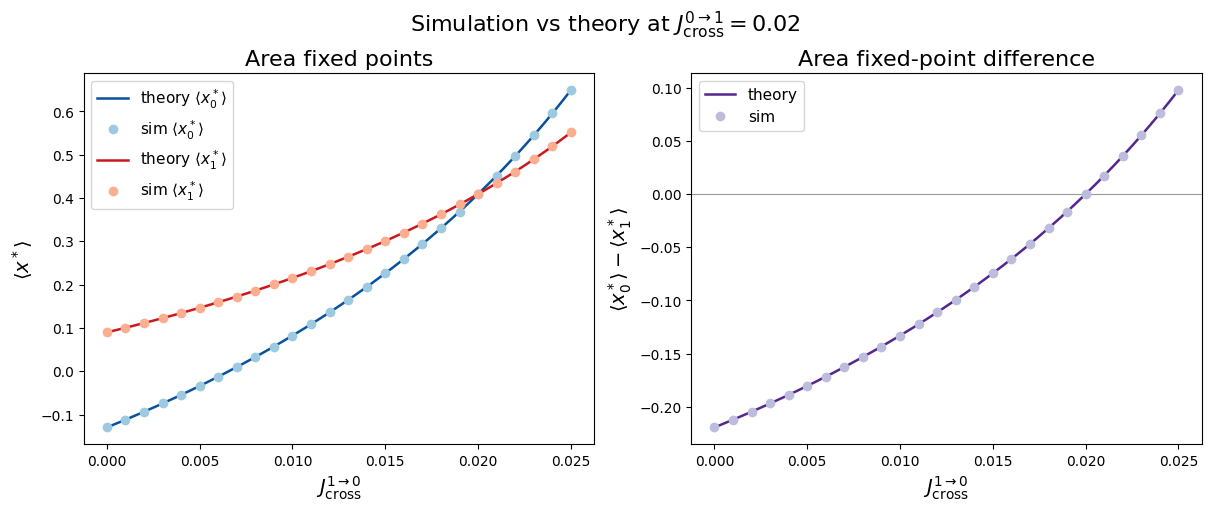

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'Area fixed points'}, xlabel='$J_{\\mathrm{cross}}^{1\\to 0}$', ylabel='$\\langle x^* \\rangle$'>,
        <Axes: title={'center': 'Area fixed-point difference'}, xlabel='$J_{\\mathrm{cross}}^{1\\to 0}$', ylabel='$\\langle x^*_0 \\rangle - \\langle x^*_1 \\rangle$'>],
       dtype=object))

In [6]:
# --- Comparison at J_cross[0,1] = 0.020 ---
compare_sim_vs_theory(
    "Data/scan/scan_cross_region_asymmetry_1D_J01_020.jsonl",
    J01=0.020,
    png_path="compare_sim_theory_1D_J01_020.png",
)

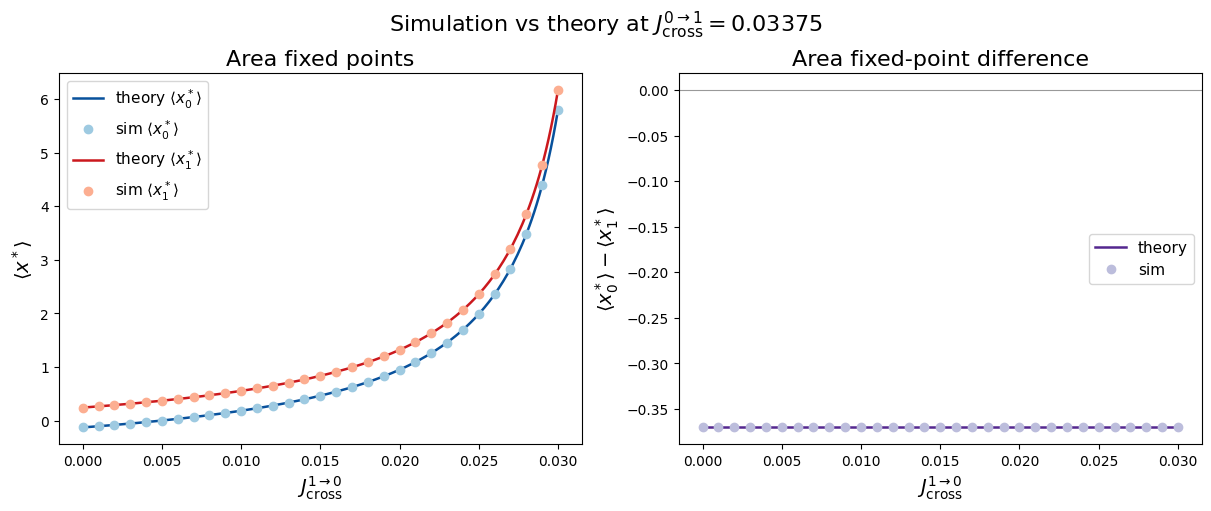

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'Area fixed points'}, xlabel='$J_{\\mathrm{cross}}^{1\\to 0}$', ylabel='$\\langle x^* \\rangle$'>,
        <Axes: title={'center': 'Area fixed-point difference'}, xlabel='$J_{\\mathrm{cross}}^{1\\to 0}$', ylabel='$\\langle x^*_0 \\rangle - \\langle x^*_1 \\rangle$'>],
       dtype=object))

In [7]:
# --- Comparison at J_cross[0,1] = 0.03375 ---
compare_sim_vs_theory(
    "Data/scan/scan_cross_region_asymmetry_1D_J01_03375.jsonl",
    J01=0.03375,
    png_path="compare_sim_theory_1D_J01_03375.png",
)

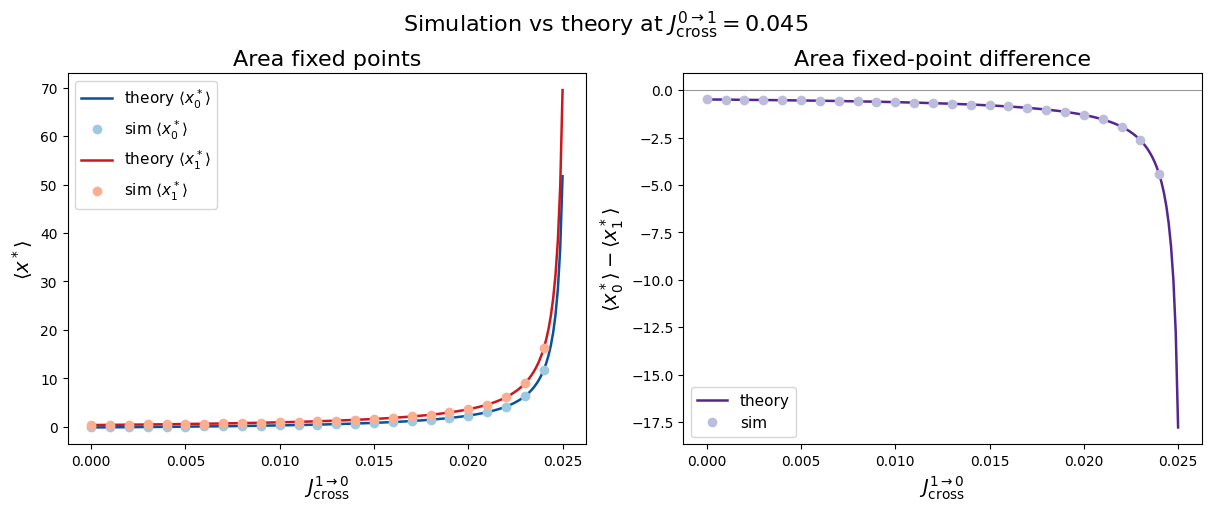

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'Area fixed points'}, xlabel='$J_{\\mathrm{cross}}^{1\\to 0}$', ylabel='$\\langle x^* \\rangle$'>,
        <Axes: title={'center': 'Area fixed-point difference'}, xlabel='$J_{\\mathrm{cross}}^{1\\to 0}$', ylabel='$\\langle x^*_0 \\rangle - \\langle x^*_1 \\rangle$'>],
       dtype=object))

In [8]:
# --- Comparison at J_cross[0,1] = 0.045 ---
compare_sim_vs_theory(
    "Data/scan/scan_cross_region_asymmetry_1D_J01_045.jsonl",
    J01=0.045,
    png_path="compare_sim_theory_1D_J01_045.png",
)